In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df = pd.read_csv("./log-[40000].csv")

df 

,Unnamed: 0,Episode,Score,Num Operations,num_jobs_completed,Epsilon,min_loss
0,0,0,159.00,52,1,1.000000,99999.000000
1,1,1,157.00,52,1,1.000000,0.000026
2,2,2,165.00,49,2,1.000000,0.000281
3,3,3,159.75,50,2,1.000000,0.000893
4,4,4,238.00,48,4,1.000000,0.023829
...,...,...,...,...,...,...,...
39995,39995,39995,149.50,48,3,0.998236,0.000945
39996,39996,39996,207.80,51,4,0.998236,0.000316
39997,39997,39997,169.75,54,2,0.998236,0.091260
39998,39998,39998,234.75,49,5,0.998236,0.003208


In [3]:
epsilon_ = df['Epsilon'] < 1
df = df[epsilon_].reset_index(drop=True,inplace=False)
df = df.drop('Unnamed: 0',axis = 1)
df

,Episode,Score,Num Operations,num_jobs_completed,Epsilon,min_loss
0,0,159.00,52,1,1.000000,99999.000000
1,1,157.00,52,1,1.000000,0.000026
2,2,165.00,49,2,1.000000,0.000281
3,3,159.75,50,2,1.000000,0.000893
4,4,238.00,48,4,1.000000,0.023829
...,...,...,...,...,...,...
39995,39995,149.50,48,3,0.998236,0.000945
39996,39996,207.80,51,4,0.998236,0.000316
39997,39997,169.75,54,2,0.998236,0.091260
39998,39998,234.75,49,5,0.998236,0.003208


In [4]:
min_score = min(list(df['Score']))
max_score = max(list(df['Score']))

print(min_score)

print(max_score)


62.0
467.35


In [28]:
import numpy as np
from scipy import stats
x=range(int(len(df['Episode'])))
y=df['Epsilon']
y2=df['Score']
y3= df['min_loss'] < 1

y3 = df.loc[df['min_loss'] < 1, 'min_loss']
print(y3)

print(np.mean(y2))

print(np.median(y2))

print(stats.mode(y2))



1        0.000026
2        0.000281
3        0.000893
4        0.023829
5        0.018240
           ...   
39995    0.000945
39996    0.000316
39997    0.091260
39998    0.003208
39999    0.000177
Name: min_loss, Length: 39999, dtype: float64
181.07735375
168.75
ModeResult(mode=157.75, count=367)


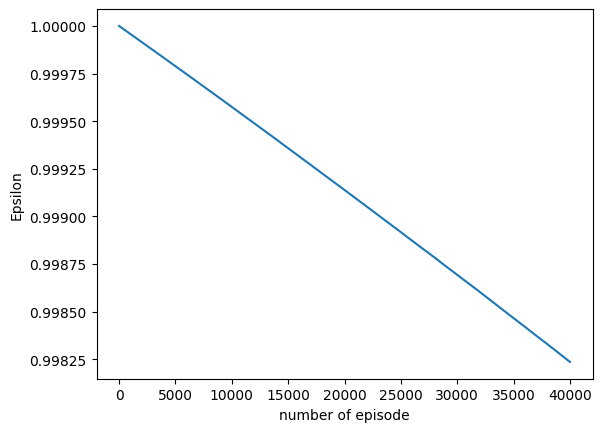

In [25]:
plt.plot(x,y)
plt.xlabel('number of episode')
plt.ylabel('Epsilon')

plt.savefig("EpsilonDecay.png")

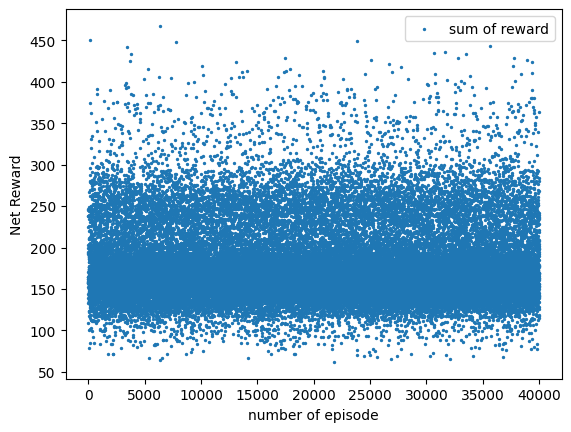

In [7]:
plt.scatter(x,y2, s=2, label='sum of reward')
#plt.plot(x,y*40, c='g', label = 'epsilon * 100')
plt.legend(loc='upper right')
plt.xlabel('number of episode')
plt.ylabel('Net Reward')

plt.savefig("NetRewardScatter.png")

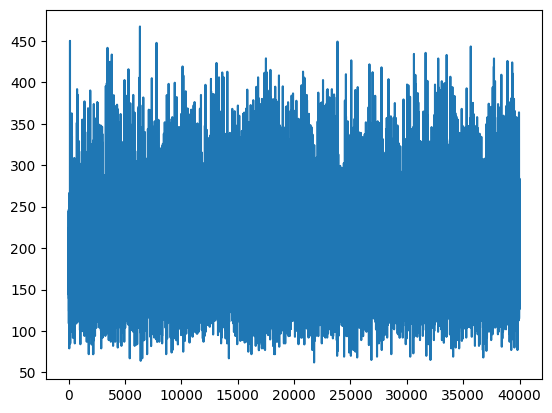

In [8]:
plt.plot(x,y2, label='sum of reward')


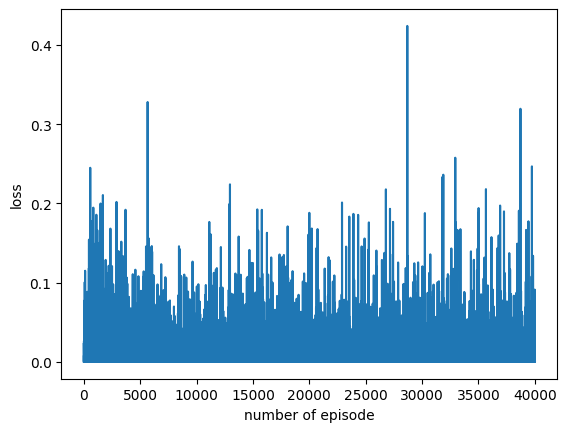

In [31]:
plt.plot(range(len(y3)),y3)
plt.xlabel('number of episode')
plt.ylabel('loss')

plt.savefig("minLoss.png")

Text(0, 0.5, 'Score')

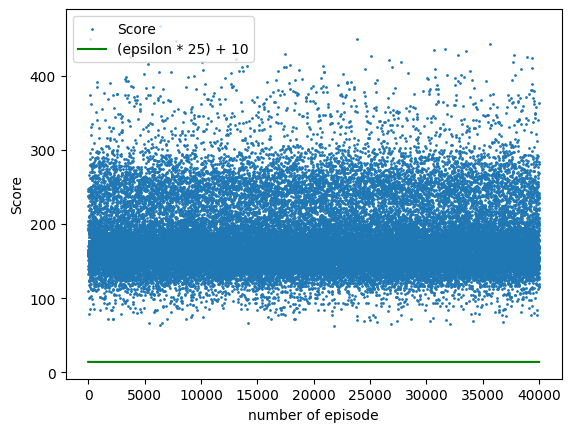

In [10]:
plt.scatter(x,y2, s=1, label='Score')
plt.plot(x,y*14, c='g', label = '(epsilon * 25) + 10')
plt.legend(loc='upper left')
plt.xlabel('number of episode')
plt.ylabel('Score')

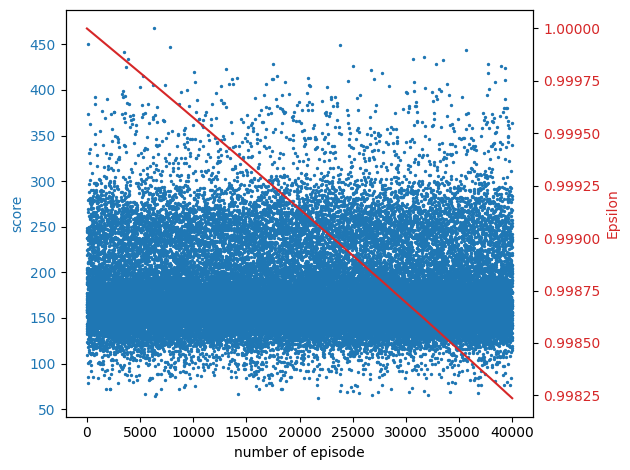

In [11]:
fig, ax1 = plt.subplots()

color = 'tab:blue'
ax1.set_xlabel('number of episode')
ax1.set_ylabel('score', color=color)
ax1.scatter(x, y2, s=2, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis

color = 'tab:red'
ax2.set_ylabel('Epsilon', color=color)  # we already handled the x-label with ax1
ax2.plot(x, y, color=color)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.show()

score / number of actions in episode. 

In [12]:
df_test = pd.read_csv("../test_log/test_log-[10000]_30000.csv")

df_test

,Unnamed: 0,Episode,Score,Num Operations,num_jobs_completed
0,0,0,171.75,52,3
1,1,1,149.75,50,3
2,2,2,164.50,52,3
3,3,3,257.60,47,5
4,4,4,168.00,52,2
...,...,...,...,...,...
235,235,55,167.50,48,4
236,236,56,157.75,52,2
237,237,57,147.75,49,3
238,238,58,177.00,52,3


In [13]:

df_test = df_test.drop('Unnamed: 0',axis = 1)
df_test

,Episode,Score,Num Operations,num_jobs_completed
0,0,171.75,52,3
1,1,149.75,50,3
2,2,164.50,52,3
3,3,257.60,47,5
4,4,168.00,52,2
...,...,...,...,...
235,55,167.50,48,4
236,56,157.75,52,2
237,57,147.75,49,3
238,58,177.00,52,3


In [14]:
x_test=range(int(len(df_test['Episode'])))
y2_test=df_test['Score']

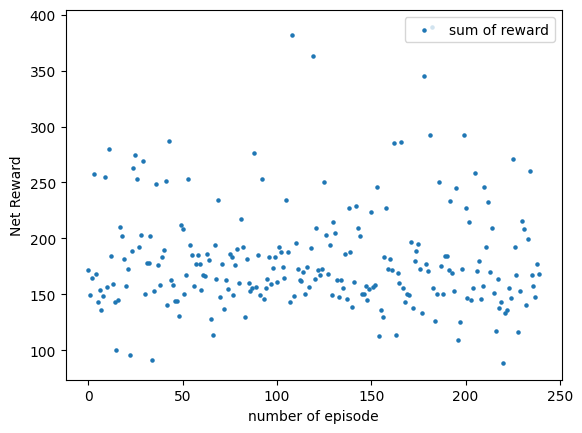

In [15]:
plt.scatter(x_test,y2_test, s=5, label='sum of reward')


#plt.plot(x,y*40, c='g', label = 'epsilon * 100')
plt.legend(loc='upper right')
plt.xlabel('number of episode')
plt.ylabel('Net Reward')

plt.savefig("NetRewardScatter_test.png")

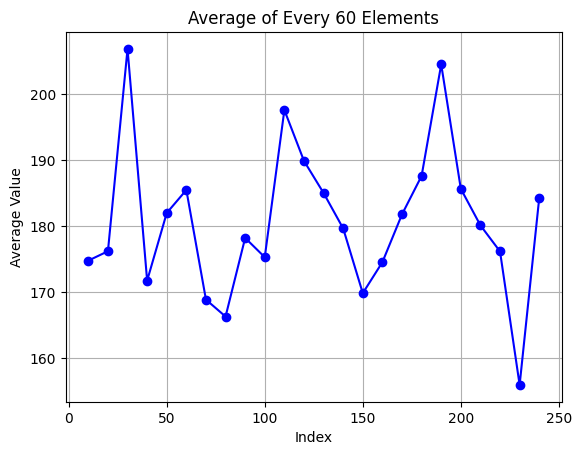

In [22]:
chunks = np.array_split(y2_test, len(y2_test)//10)

# Calculate the average for each chunk
averages = [np.mean(chunk) for chunk in chunks]

# Create a list of indices for the x-axis
indices = [(i+1)*10 for i in range(len(chunks))]

# Plot the graph
plt.plot(indices, averages, marker='o', linestyle='-', color='b')
plt.title('Average of Every 60 Elements')
plt.xlabel('Index')
plt.ylabel('Average Value')
plt.grid(True)
plt.show()

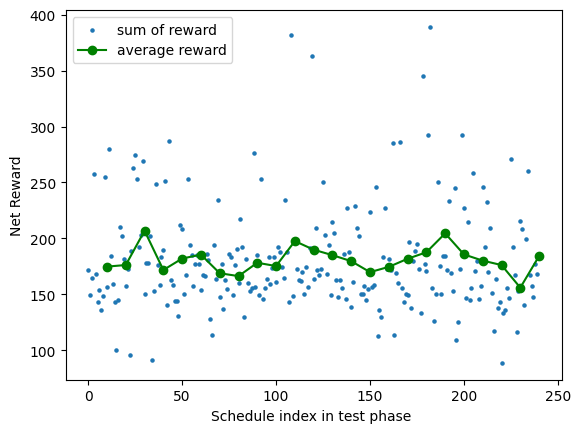

In [23]:
plt.scatter(x_test,y2_test, s=5, label='sum of reward')
plt.plot(indices, averages, marker='o', linestyle='-', color='green', label= 'average reward')
plt.legend(loc='upper left')
plt.xlabel('Schedule index in test phase ')
plt.ylabel('Net Reward')

plt.savefig("RewardsTest.png")

In [18]:
max_score_test = max(y2_test)
min_score_test = min(y2_test)

print(max_score_test)
print(min_score_test)

print(np.mean(y2_test))

389.0
88.75
180.7935416666667
